# Global statistics of the dataset

This notebook gives some statistics of the dataset considering the questionnaires and trajectories of visitors. 

In [1]:
import os
import pandas as pd
import math
import seaborn as sns
import matplotlib.pyplot as plt

## Get global statistics of trajectories

### Mean duration of item observation

In [2]:
folder_items_end = "../data/end_obs_artworks/"
folder_items_beg = "../data/start_obs_artworks/"
folder_questionnaires= "../data/questionnaires/"
folder_normalized_trajs = '../data/normalized_trajectories/'


#Obtaining mean duration of items observation
def getDuration(row, itemsBeg):
    same_items_beg = itemsBeg[row.paintingId == itemsBeg.paintingId]
    if (len(same_items_beg)==1):
        return (row.timestamp - same_items_beg.iloc[0].timestamp)
    else:
        filter_soustraction = same_items_beg[same_items_beg['timestamp'] <= row.timestamp]
        idx_min = (filter_soustraction['timestamp'] - row.timestamp).idxmin()
        ligne_plus_proche = filter_soustraction.loc[idx_min]
        return (row.timestamp - ligne_plus_proche.timestamp)


all_durations=[]
for file_item_end in os.listdir(folder_items_end): 
    name_user="items_"+file_item_end[6:-8]
    fileItem_endPath = os.path.join(folder_items_end,name_user+"_end.csv")
    fileItemPath = os.path.join(folder_items_beg, name_user+ ".csv")
    with open(fileItem_endPath, 'r') as fileEnd, open(fileItemPath, 'r') as fileBeg:
        itemsEnd = pd.read_csv(fileEnd)
        itemsBeg = pd.read_csv(fileBeg)
        durations = []
        durations = itemsEnd.apply(lambda row: getDuration(row, itemsBeg), axis=1).tolist()
        all_durations.extend(durations)

   
durations_filtrees = [d for d in all_durations if not math.isnan(d)]

#Get the mean duration in seconds
mean_duration = sum(durations_filtrees)/len(durations_filtrees)
print("Mean duration of observation: "+ str(mean_duration)+ " seconds")

Mean duration of observation: 29.33330214767484 seconds


### Duration of visit

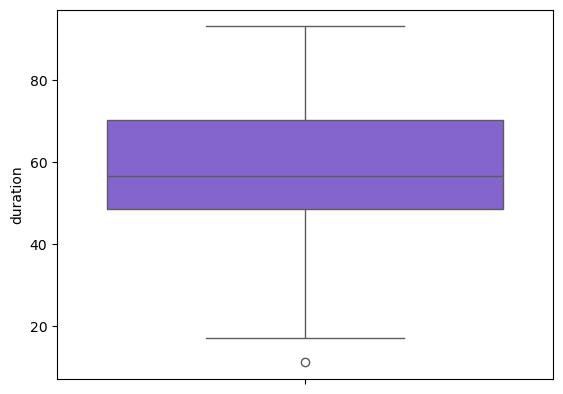

In [3]:
df_trajs = pd.read_csv ("../data/semantic_info_entire_trajectories.csv")

#Boxplot of the duration of visits in minutes
sns.boxplot(y=df_trajs['duration']/60, color= "#7d54de")
plt.show()

### Length of visit

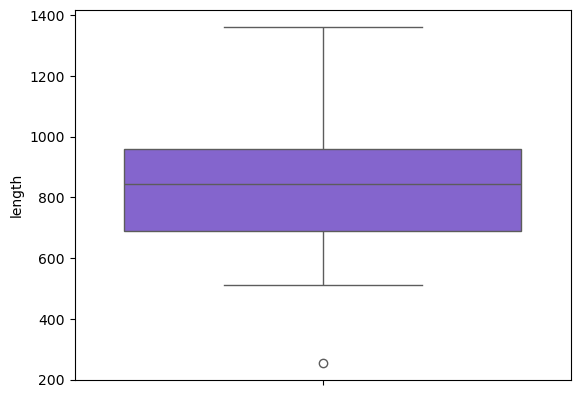

In [4]:
#Boxplot of the length of visit in meters
sns.boxplot(y=df_trajs['length']/100, color="#7d54de")
plt.show()

### Number of items seen

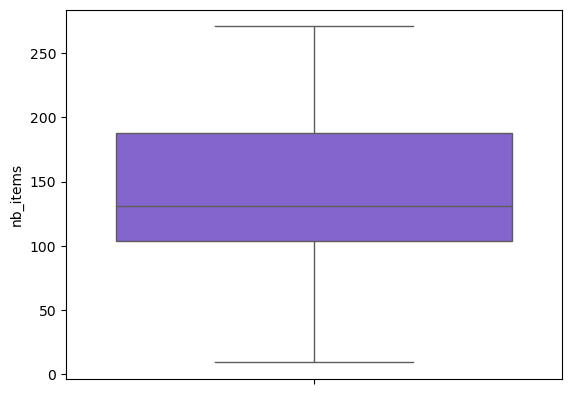

In [5]:
#Boxplot of items seen
sns.boxplot(y=df_trajs['nb_items'], color="#7d54de")
plt.show()

## Global statistics of questionnaires

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df_pre = pd.read_csv(folder_questionnaires+'pre_questionnaire_formatted.csv')
df_post = pd.read_csv(folder_questionnaires+'post_questionnaire_formatted.csv')
df_merged_questions = pd.merge(df_pre, df_post, on='visitor_id', how='inner')
df_merged_questions.rename(columns={"passation_hour_x":'passationBeforeVisit',"passation_hour_y":"passationAfterVisit"},inplace=True)


#Get the information of the 51 visitors of the dataset
trajectories_dataset = [int(f[0:12]) for f in os.listdir(folder_normalized_trajs) if os.path.isfile(os.path.join(folder_normalized_trajs, f))]

dataset=df_merged_questions[df_merged_questions.visitor_id.isin(trajectories_dataset)]
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51 entries, 1 to 115
Data columns (total 90 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   passationBeforeVisit           51 non-null     object
 1   visitor_id                     51 non-null     int64 
 2   age                            51 non-null     int64 
 3   gender                         51 non-null     object
 4   city_country_residence         51 non-null     object
 5   nationality                    51 non-null     object
 6   french_level                   51 non-null     object
 7   diploma                        51 non-null     object
 8   one_artwork_interest           51 non-null     int64 
 9   discovery_interest             51 non-null     int64 
 10  crowd_tolerance                51 non-null     int64 
 11  lose_interest_with_crowd       51 non-null     int64 
 12  distance_tolerance             51 non-null     int64 
 13  already_vis

C:\Users\Alexanne\AppData\Local\Temp\ipykernel_18268\1865939631.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset, x="age",y="gender", palette=custom_palette)


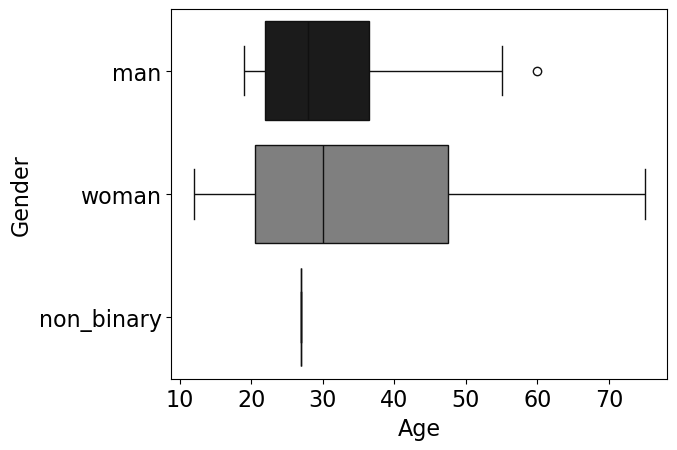

In [7]:
custom_palette = ['#1b1b1b', '#7f7f7f', '#d9d9d9']

sns.boxplot(data=dataset, x="age",y="gender", palette=custom_palette)
plt.xlabel('Age',  fontsize=16)
plt.xticks(fontsize=16)
plt.ylabel('Gender', fontsize=16)
plt.yticks(fontsize=16)

plt.show()

C:\Users\Alexanne\AppData\Local\Temp\ipykernel_18268\2776921728.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='gender', data=dataset, palette=custom_palette)


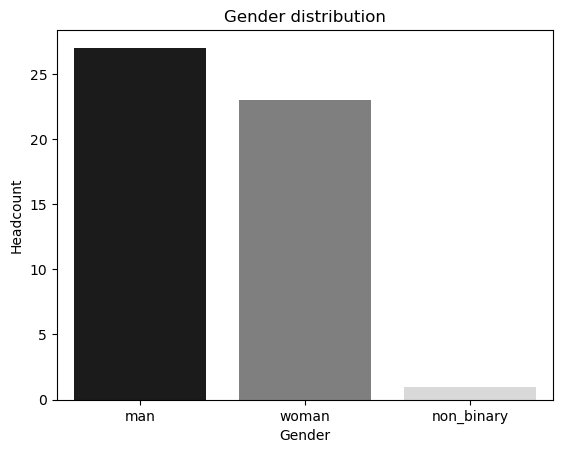

In [8]:
custom_palette = ['#1b1b1b', '#7f7f7f', '#d9d9d9']
sns.countplot(x='gender', data=dataset, palette=custom_palette)
plt.xlabel('Gender')
plt.ylabel('Headcount')
plt.title('Gender distribution')
plt.show()

C:\Users\Alexanne\AppData\Local\Temp\ipykernel_18268\2543601738.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax= sns.countplot(x='diploma', data=dataset, palette=custom_palette)
C:\Users\Alexanne\AppData\Local\Temp\ipykernel_18268\2543601738.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["MS/MSc", 'BA, BS/BSc',"BTEC_first","PhD","BTEC HND","A levels","No diploma",'Middle school'], rotation=45)


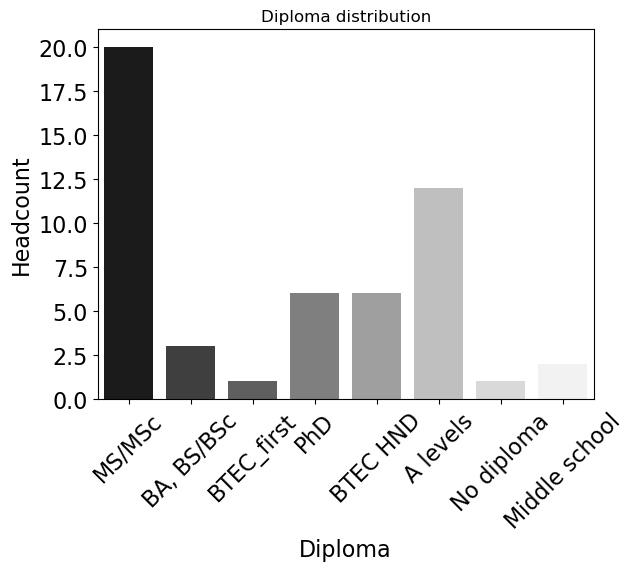

In [9]:
custom_palette = [
    '#1b1b1b',  
    '#3f3f3f',  
    '#5f5f5f',  
    '#7f7f7f',  
    '#9f9f9f',  
    '#bfbfbf',  
    '#d9d9d9',  
    '#f2f2f2'   
]
ax= sns.countplot(x='diploma', data=dataset, palette=custom_palette)

ax.set_xticklabels(["MS/MSc", 'BA, BS/BSc',"BTEC_first","PhD","BTEC HND","A levels","No diploma",'Middle school'], rotation=45)
plt.xlabel('Diploma', fontsize=16)
plt.xticks(fontsize=16)
plt.ylabel('Headcount', fontsize=16)
plt.yticks(fontsize=16)
plt.title('Diploma distribution')
plt.show()

C:\Users\Alexanne\AppData\Local\Temp\ipykernel_18268\3135189579.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='group_or_alone', data=dataset, palette=custom_palette)


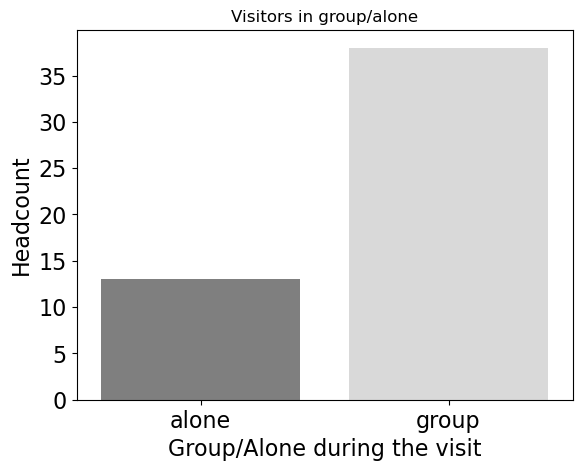

In [10]:
custom_palette = [ '#7f7f7f', '#d9d9d9']
sns.countplot(x='group_or_alone', data=dataset, palette=custom_palette)
plt.xlabel('Group/Alone during the visit', fontsize=16)
plt.xticks(fontsize=16)
plt.ylabel('Headcount', fontsize=16)
plt.yticks(fontsize=16)
plt.title('Visitors in group/alone')
plt.show()

C:\Users\Alexanne\AppData\Local\Temp\ipykernel_18268\440696202.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Column', y='Occurrences', data=count_ones, palette=custom_palette)


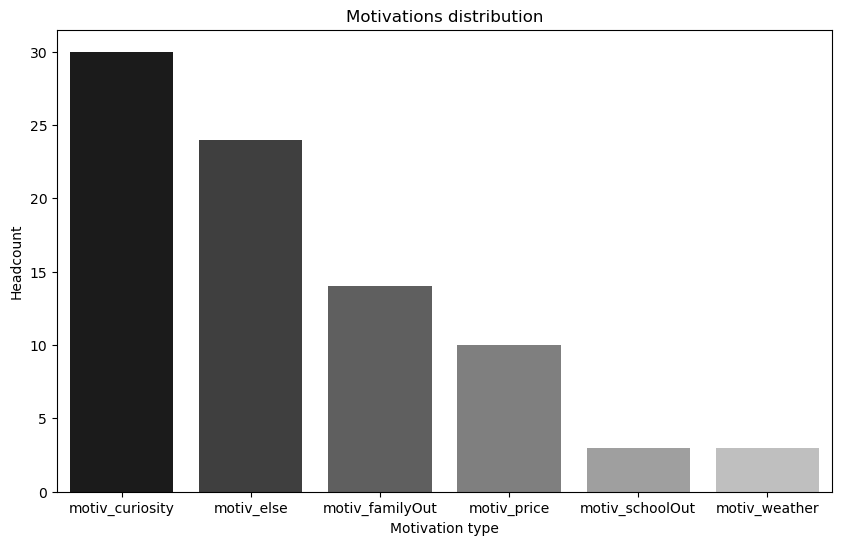

In [11]:
df_motiv=dataset[['motiv_curiosity','motiv_else', 'motiv_familyOut', 'motiv_price', 'motiv_schoolOut','motiv_weather']]

count_ones = (df_motiv == 1).sum().reset_index()
count_ones.columns = ['Column', 'Occurrences']

custom_palette = [
    '#1b1b1b',  
    '#3f3f3f',  
    '#5f5f5f',  
    '#7f7f7f', 
    '#9f9f9f',  
    '#bfbfbf',  
]

plt.figure(figsize=(10, 6))
sns.barplot(x='Column', y='Occurrences', data=count_ones, palette=custom_palette)
plt.xlabel('Motivation type')
plt.ylabel('Headcount')
plt.title('Motivations distribution')
plt.show()

C:\Users\Alexanne\AppData\Local\Temp\ipykernel_18268\2216880125.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(x='Column', y='Occurrences', data=count_ones, palette=custom_palette)
C:\Users\Alexanne\AppData\Local\Temp\ipykernel_18268\2216880125.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Surprised","Else","Explore","Inspiration","Fun",'Interact','Learn','No goal','See Again',"MindOff"], rotation=45)


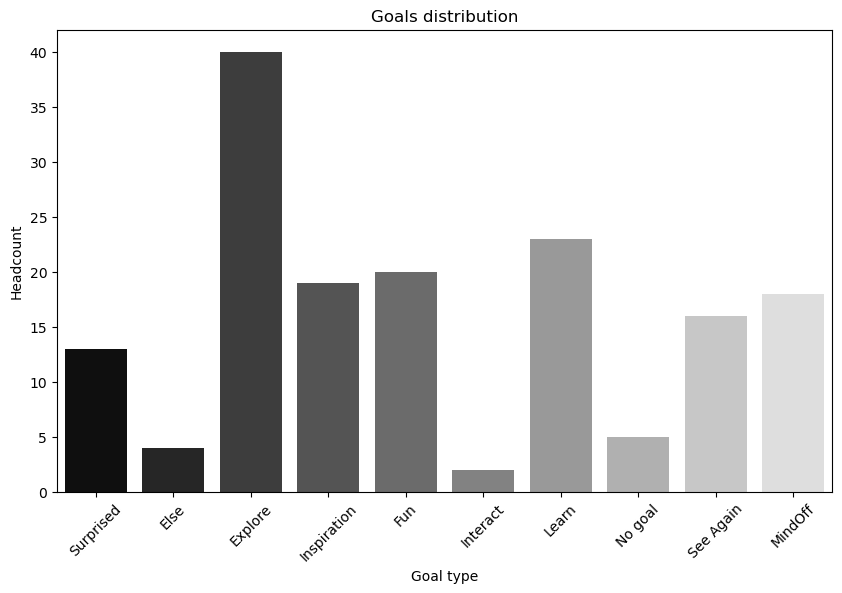

In [12]:
df_goal=dataset[['visitGoal_surprised', 'visitGoal_else',
       'visitGoal_explore', 'visitGoal_inspiration', 'visitGoal_fun',
       'visitGoal_interact', 'visitGoal_learn', 'visitGoal_noGoal',
       'visitGoal_SeeAgain', 'visitGoal_mindOff']]

count_ones = (df_goal == 1).sum().reset_index()
count_ones.columns = ['Column', 'Occurrences']

custom_palette = [
    '#0f0f0f',  
    '#262626',
    '#3d3d3d',
    '#545454',
    '#6b6b6b',
    '#828282',
    '#999999',
    '#b0b0b0',
    '#c7c7c7',
    '#dedede'  
]
plt.figure(figsize=(10, 6))

ax=sns.barplot(x='Column', y='Occurrences', data=count_ones, palette=custom_palette)
ax.set_xticklabels(["Surprised","Else","Explore","Inspiration","Fun",'Interact','Learn','No goal','See Again',"MindOff"], rotation=45)
plt.xlabel('Goal type')
plt.ylabel('Headcount')
plt.title('Goals distribution')
plt.show()